Panen yang tertinggal

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ASEAN8 = ["Indonesia", "Vietnam", "Thailand", "Philippines",
          "Myanmar", "Cambodia", "Laos", "Malaysia"]
NAMA_ID = {"Indonesia": "Indonesia", "Vietnam": "Vietnam", "Thailand": "Thailand",
           "Philippines": "Filipina", "Myanmar": "Myanmar", "Cambodia": "Kamboja",
           "Laos": "Laos", "Malaysia": "Malaysia"}
WARNA_HIGHLIGHT, WARNA_NETRAL = "#D64545", "#4C72B0"

RICE_URL = "/content/rice-yields.csv"

# fallback: titik 1990 & 2024 (t/ha), tervalidasi cocok dgn dokumen
_rice_fallback = pd.DataFrame({
    "Entity": ASEAN8,
    "Year_1990": [4.30, 3.18, 1.96, 2.98, 2.94, 1.35, 2.29, 2.77],
    "Year_2024": [5.29, 6.15, 2.98, 4.11, 3.94, 3.64, 4.11, 3.54],
})

try:
    rice_raw = pd.read_csv(RICE_URL, storage_options={"User-Agent": "notebook/1.0"})
    print("[OK] Data diambil langsung dari OWID.")
except Exception as e:
    print(f"[INFO] Gagal akses OWID ({e}); pakai data cadangan.")
    rice_raw = _rice_fallback.copy()

rice_raw.head()

[INFO] Gagal akses OWID (storage_options passed with file object or non-fsspec file path); pakai data cadangan.


,Entity,Year_1990,Year_2024
0,Indonesia,4.30,5.29
1,Vietnam,3.18,6.15
2,Thailand,1.96,2.98
3,Philippines,2.98,4.11
4,Myanmar,2.94,3.94


In [4]:
value_col = [c for c in rice_raw.columns if "yield" in c.lower()]

if value_col:
    df = rice_raw[rice_raw["Entity"].isin(ASEAN8)]
    df = df[df["Year"].isin([1990, 2024])]
    pivot_rice = df.pivot(index="Entity", columns="Year", values=value_col[0])
    pivot_rice.columns = ["Year_1990", "Year_2024"]
    pivot_rice = pivot_rice.reset_index()
else:
    pivot_rice = rice_raw.copy()

pivot_rice["Perubahan_%"] = (pivot_rice["Year_2024"] / pivot_rice["Year_1990"] - 1) * 100
pivot_rice["CAGR_%"] = ((pivot_rice["Year_2024"] / pivot_rice["Year_1990"]) ** (1/34) - 1) * 100
pivot_rice["Negara"] = pivot_rice["Entity"].map(NAMA_ID)
pivot_rice = pivot_rice.sort_values("Perubahan_%", ascending=False).reset_index(drop=True)

pivot_rice[["Negara", "Year_1990", "Year_2024", "Perubahan_%", "CAGR_%"]]

,Negara,Year_1990,Year_2024,Perubahan_%,CAGR_%
0,Kamboja,1.35,3.64,169.629630,2.960261
1,Vietnam,3.18,6.15,93.396226,1.958853
2,Laos,2.29,4.11,79.475983,1.735090
3,Thailand,1.96,2.98,52.040816,1.239915
4,Filipina,2.98,4.11,37.919463,0.950072
5,Myanmar,2.94,3.94,34.013605,0.864810
6,Malaysia,2.77,3.54,27.797834,0.724018
7,Indonesia,4.30,5.29,23.023256,0.611282


In [5]:
value_col = [c for c in rice_raw.columns if "yield" in c.lower()]

if value_col:
    df = rice_raw[rice_raw["Entity"].isin(ASEAN8)]
    df = df[df["Year"].isin([1990, 2024])]
    pivot_rice = df.pivot(index="Entity", columns="Year", values=value_col[0])
    pivot_rice.columns = ["Year_1990", "Year_2024"]
    pivot_rice = pivot_rice.reset_index()
else:
    pivot_rice = rice_raw.copy()

pivot_rice["Perubahan_%"] = (pivot_rice["Year_2024"] / pivot_rice["Year_1990"] - 1) * 100
pivot_rice["CAGR_%"] = ((pivot_rice["Year_2024"] / pivot_rice["Year_1990"]) ** (1/34) - 1) * 100
pivot_rice["Negara"] = pivot_rice["Entity"].map(NAMA_ID)
pivot_rice = pivot_rice.sort_values("Perubahan_%", ascending=False).reset_index(drop=True)

pivot_rice[["Negara", "Year_1990", "Year_2024", "Perubahan_%", "CAGR_%"]]

,Negara,Year_1990,Year_2024,Perubahan_%,CAGR_%
0,Kamboja,1.35,3.64,169.629630,2.960261
1,Vietnam,3.18,6.15,93.396226,1.958853
2,Laos,2.29,4.11,79.475983,1.735090
3,Thailand,1.96,2.98,52.040816,1.239915
4,Filipina,2.98,4.11,37.919463,0.950072
5,Myanmar,2.94,3.94,34.013605,0.864810
6,Malaysia,2.77,3.54,27.797834,0.724018
7,Indonesia,4.30,5.29,23.023256,0.611282


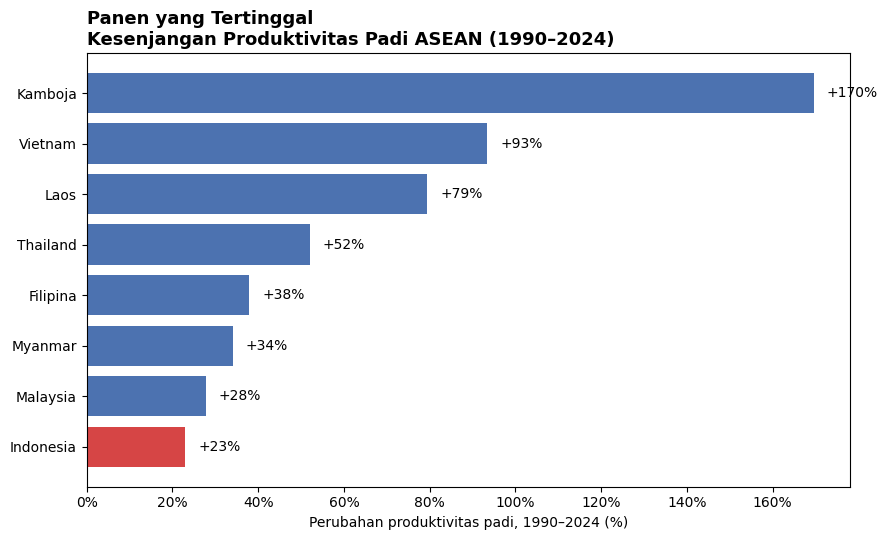

In [6]:
plot_df = pivot_rice.sort_values("Perubahan_%", ascending=True)
colors = [WARNA_HIGHLIGHT if e == "Indonesia" else WARNA_NETRAL for e in plot_df["Entity"]]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(plot_df["Negara"], plot_df["Perubahan_%"], color=colors)
for bar, pct in zip(bars, plot_df["Perubahan_%"]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, f"+{pct:.0f}%", va="center")

ax.set_xlabel("Perubahan produktivitas padi, 1990–2024 (%)")
ax.set_title("Panen yang Tertinggal\nKesenjangan Produktivitas Padi ASEAN (1990–2024)",
             fontsize=13, fontweight="bold", loc="left")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
plt.tight_layout()
plt.show()